# Finalize surrogate + oracle

Take the **top-2 readouts** from the random-split sweep (**CNN-max**, **MLP-max**) and train **each on its own
random split** (different seed → decorrelated data; different architecture → decorrelated inductive bias).
Visualize predictions on **validation and test**, then save the **better model as the oracle** (the trusted
evaluator) and the **second as the surrogate** (the design guide). Both are saved for
`guided_design_approach1.ipynb`.

## 0. Setup + data

In [1]:
import csv, os, numpy as np, torch, torch.nn as nn
import arcadia_pycolor as apc
import fp_models as fpm
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True; apc.mpl.setup()
except Exception: HAVE_PLT=False
TD="training_data"; DS=os.path.join("..","fpbase-extractor","processed_data","ESM-spectrum")
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(TD,"split_assignments.csv")))); N=len(rows)
Y=np.load(os.path.join(TD,"spectra.npy")).astype(np.float32); grid=np.load(os.path.join(DS,"grid_nm.npy")); G=len(grid)
EXM=np.array([float(r["ex_max"]) for r in rows]); EMM=np.array([float(r["em_max"]) for r in rows])
H=np.load(os.path.join(TD,"esm_residue_fp16.npy")); Ls=np.load(os.path.join(TD,"esm_residue_len.npy")); Lmax=H.shape[1]
Ht=torch.tensor(H); ar=torch.arange(Lmax)
os.makedirs("trained_models", exist_ok=True)
print("device",dev,"| N",N,"| spectrum dim",Y.shape[1])

device mps | N 453 | spectrum dim 1002


## 1. Train each top model on its own random split

In [2]:
CONV_CH=128; KSIZE=5; HIDDEN=256; NL=2; DROP=0.2; LR=1e-3; WD=1e-4; EPOCHS=200
TOP2=[dict(name="CNN-max", arch="CNN", pool="max", split_seed=0),
      dict(name="MLP-max", arch="MLP", pool="max", split_seed=1)]

def random_split(seed):
    rng=np.random.default_rng(seed); perm=rng.permutation(N)
    nval=int(round(0.15*N)); ntest=int(round(0.15*N))
    s=np.array(["train"]*N); s[perm[:ntest]]="test"; s[perm[ntest:ntest+nval]]="val"
    return {b:np.where(s==b)[0] for b in("train","val","test")}

def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),torch.tensor(Y[b]).to(dev)

def exem(S): return grid[np.argmax(S[:,:G],1)], grid[np.argmax(S[:,G:],1)]
def evaluate(net,idx):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,yb in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    P=np.concatenate(ps); T=Y[idx]; ex,em=exem(P)
    return dict(mse=float(((P-T)**2).mean()), ex_mae=float(np.abs(ex-EXM[idx]).mean()),
                em_mae=float(np.abs(em-EMM[idx]).mean()))

def train_model(spec):
    sp=random_split(spec["split_seed"])
    torch.manual_seed(0)
    net=fpm.SpectrumNet(spec["pool"], spec["arch"]=="CNN", conv_ch=CONV_CH, k=KSIZE,
                        hidden=HIDDEN, nl=NL, drop=DROP, out=2*G).to(dev)
    opt=torch.optim.Adam(net.parameters(), LR, weight_decay=WD); lf=nn.MSELoss(); best=1e9; bst=None; bep=0
    for ep in range(EPOCHS):
        net.train()
        for Hb,mk,yb in batches(sp["train"], shuffle=True):
            opt.zero_grad(); lf(net(Hb,mk),yb).backward(); opt.step()
        v=evaluate(net,sp["val"])["mse"]
        if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.state_dict().items()}; bep=ep
    net.load_state_dict(bst)
    return net, sp, dict(val=evaluate(net,sp["val"]), test=evaluate(net,sp["test"]), ep=bep)

results=[]
for spec in TOP2:
    net,sp,met=train_model(spec)
    results.append(dict(spec=spec, net=net, split=sp, met=met))
    print(f"{spec['name']:8s} (split seed {spec['split_seed']}, best ep {met['ep']:3d}) | "
          f"val MSE {met['val']['mse']:.5f} em {met['val']['em_mae']:.1f} | "
          f"test MSE {met['test']['mse']:.5f} em {met['test']['em_mae']:.1f}")

CNN-max  (split seed 0, best ep 157) | val MSE 0.02447 em 20.2 | test MSE 0.02146 em 13.7


MLP-max  (split seed 1, best ep 177) | val MSE 0.02993 em 22.1 | test MSE 0.03081 em 25.9


## 2. Prediction vs ground truth — validation & test (per model)

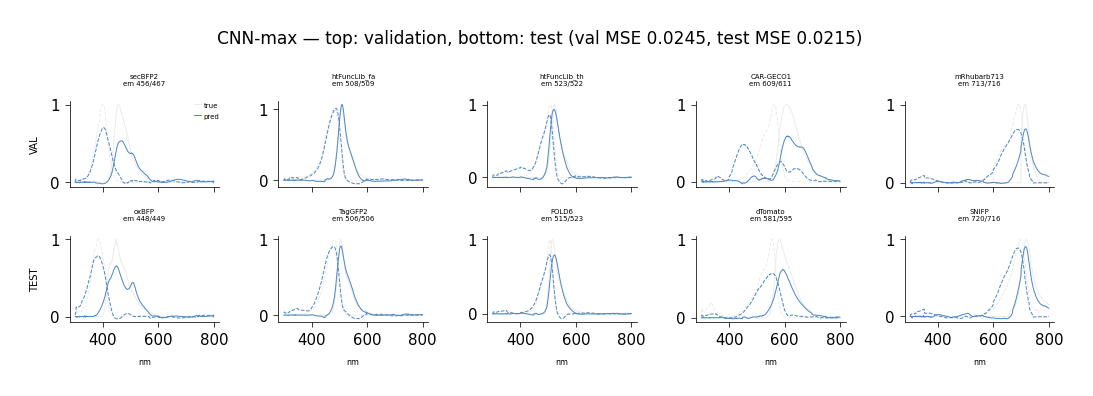

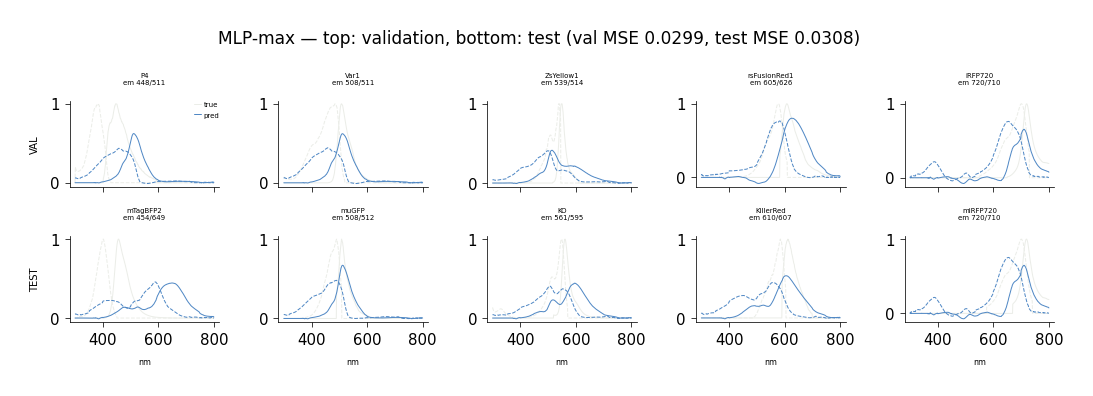

In [3]:
def predict(net,idx):
    idx=np.array(idx); Hb=Ht[idx].float().to(dev)
    mask=(ar.unsqueeze(0)<torch.tensor(Ls[idx]).unsqueeze(1)).to(dev); net.eval()
    with torch.no_grad(): return net(Hb,mask).cpu().numpy()
def span(idx,k):
    idx=np.array(idx); order=idx[np.argsort(EMM[idx])]
    return order[np.linspace(0,len(order)-1,min(k,len(order))).astype(int)]

if HAVE_PLT:
    K=5
    for r in results:
        net=r["net"]; sp=r["split"]; name=r["spec"]["name"]
        fig,axes=plt.subplots(2,K,figsize=(3*K,5),sharex=True)
        for row,split in enumerate(["val","test"]):
            sel=span(sp[split],K); P=predict(net,sel)
            for c,i in enumerate(sel):
                ax=axes[row,c]
                ax.plot(grid,Y[i,:G],color=apc.gray,ls="--",lw=1); ax.plot(grid,Y[i,G:],color=apc.gray,ls="-",lw=1,label="true")
                ax.plot(grid,P[c,:G],color=apc.aegean,ls="--",lw=1); ax.plot(grid,P[c,G:],color=apc.aegean,ls="-",lw=1,label="pred")
                ax.set_title(f"{rows[i]['name'][:12]}\nem {EMM[i]:.0f}/{grid[np.argmax(P[c,G:])]:.0f}",fontsize=7)
                if row==1: ax.set_xlabel("nm",fontsize=8)
                if c==0: ax.set_ylabel(split.upper(),fontsize=10)
        axes[0,0].legend(fontsize=7)
        plt.suptitle(f"{name} — top: validation, bottom: test "
                     f"(val MSE {r['met']['val']['mse']:.4f}, test MSE {r['met']['test']['mse']:.4f})")
        plt.tight_layout(); plt.show()

## 3. Save: best → oracle, second → surrogate

In [4]:
ranked=sorted(results, key=lambda r: r["met"]["val"]["mse"])   # best (lowest val MSE) first
roles=[("oracle", ranked[0]), ("surrogate", ranked[1])]
for role, r in roles:
    spec=r["spec"]
    meta=dict(arch=spec["arch"], pool=spec["pool"], conv_ch=CONV_CH, k=KSIZE, hidden=HIDDEN, nl=NL, drop=DROP,
              out=2*G, split_seed=spec["split_seed"], role=role,
              val_mse=r["met"]["val"]["mse"], test_mse=r["met"]["test"]["mse"])
    path=os.path.join("trained_models", f"{role}_net.pt")
    fpm.save_model(path, r["net"], meta)
    print(f"{role:9s} <- {spec['name']:8s} | val MSE {meta['val_mse']:.5f} test MSE {meta['test_mse']:.5f} | saved {path}")
print("\noracle = best (most accurate judge); surrogate = second (design guide); different architectures + splits.")

oracle    <- CNN-max  | val MSE 0.02447 test MSE 0.02146 | saved trained_models/oracle_net.pt
surrogate <- MLP-max  | val MSE 0.02993 test MSE 0.03081 | saved trained_models/surrogate_net.pt

oracle = best (most accurate judge); surrogate = second (design guide); different architectures + splits.


## Notes
- `trained_models/oracle_net.pt` and `surrogate_net.pt` carry their config (arch/pool/hyperparameters), so
  `fp_models.load_model(...)` reconstructs them anywhere. `guided_design_approach1.ipynb` loads both.
- Surrogate and oracle differ in **architecture** (CNN vs MLP) **and training split** (different random seeds)
  — decorrelating their errors so the oracle is a fairer independent judge of surrogate-guided designs.